In [5]:
import pandas as pd
import yfinance as yf

ticker = yf.Ticker("BTC-USD")

In [8]:
data = ticker.history(period='5d',
interval='1m',
actions=True,
auto_adjust=True)

print(data)

                                   Open          High           Low  \
Datetime                                                              
2022-01-14 00:00:00+00:00  42598.871094  42598.871094  42598.871094   
2022-01-14 00:01:00+00:00  42621.824219  42621.824219  42621.824219   
2022-01-14 00:02:00+00:00  42632.761719  42632.761719  42632.761719   
2022-01-14 00:03:00+00:00  42607.000000  42607.000000  42607.000000   
2022-01-14 00:05:00+00:00  42545.308594  42545.308594  42545.308594   
...                                 ...           ...           ...   
2022-01-18 10:31:00+00:00  41958.355469  41958.355469  41958.355469   
2022-01-18 10:32:00+00:00  41960.558594  41960.558594  41960.558594   
2022-01-18 10:33:00+00:00  41966.804688  41966.804688  41966.804688   
2022-01-18 10:34:00+00:00  41990.609375  41990.609375  41990.609375   
2022-01-18 10:35:00+00:00  42001.039062  42001.039062  42001.039062   

                                  Close    Volume  Dividends  Stock Splits  

In [32]:
import pandas as pd
import pandas_datareader.data as web
import datetime
start = pd.to_datetime('2022-01-01')

end = start + datetime.timedelta(days=2) # or datetime objects
btc_df = web.DataReader('BTC-USD', 'yahoo', start=start, end=end)
btc_df.index

DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04'], dtype='datetime64[ns]', name='Date', freq=None)

In [14]:
import pandas_datareader.data as web
import datetime as dt

ticker = 'BTC-USD'


start = dt.datetime(2022, 1, 1)
for i in range(24):
    end = start + dt.timedelta(hours=1)
    prices = web.DataReader(ticker, 'yahoo', start, end)
    last_price = prices[-1]
    print(prices)
    start=end

Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Close, dtype: float64
Date
2022-01-01    47686.81250
2022-01-02    47345.21875
Name: Cl

In [36]:
import pandas as pd
from pandas_datareader import data, wb
import matplotlib as mpl
from mpl_finance import candlestick_ohlc
import matplotlib.dates as dates
import datetime
import matplotlib.pyplot as plt
%matplotlib inline

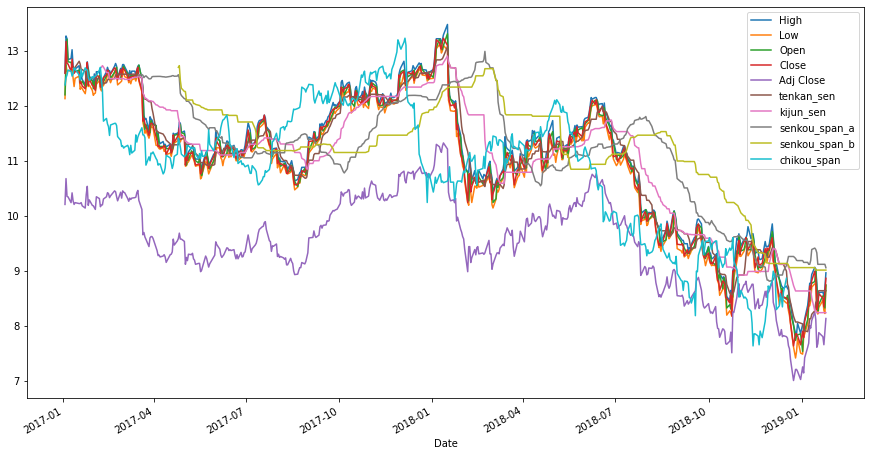

In [40]:
import matplotlib.pyplot as plt
start = datetime.datetime(2017, 1, 1)
end = datetime.datetime(2019, 1, 27)
d=data.DataReader("F", 'yahoo', start, end)


# convert dates to integer values for later use with the
# matplotlib candlestick charting function (it doesn't accept datetimes)
d['Dates'] = dates.date2num(d.index)

# Tenkan-sen (Conversion Line): (9-period high + 9-period low)/2))
nine_period_high = d['High'].rolling(window= 9).max()
nine_period_low = d['Low'].rolling(window= 9).min()
d['tenkan_sen'] = (nine_period_high + nine_period_low) / 2

# Kijun-sen (Base Line): (26-period high + 26-period low)/2))
period26_high = d['High'].rolling(window=26).max()
period26_low = d['Low'].rolling(window=26).min()
d['kijun_sen'] = (period26_high + period26_low) / 2

# Senkou Span A (Leading Span A): (Conversion Line + Base Line)/2))
d['senkou_span_a'] = ((d['tenkan_sen'] + d['kijun_sen']) / 2).shift(26)

# Senkou Span B (Leading Span B): (52-period high + 52-period low)/2))
period52_high = d['High'].rolling(window=52).max()
period52_low = d['Low'].rolling(window=52).min()
d['senkou_span_b'] = ((period52_high + period52_low) / 2).shift(26)

# The most current closing price plotted 26 time periods behind (optional)
d['chikou_span'] = d['Close'].shift(-26)

# create a quick plot of the results to see what we have created
d.drop(['Dates', 'Volume'], axis=1).plot(figsize=(15,8))
plt.show()

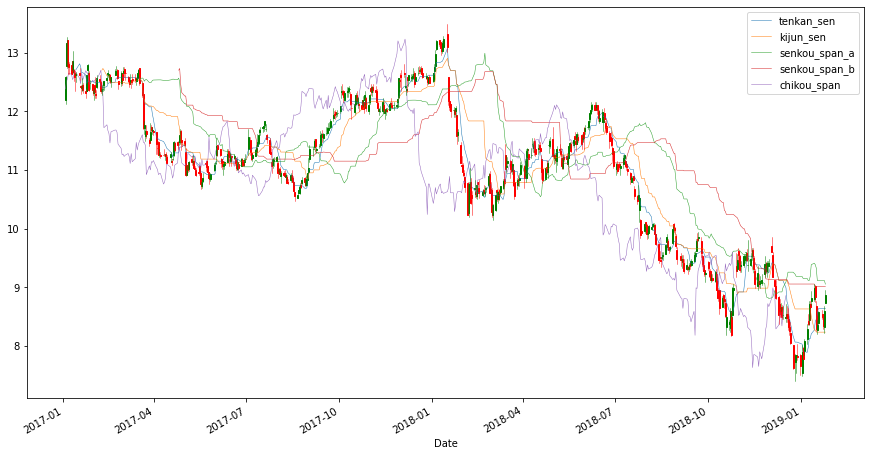

In [25]:
# Re-arrange data so that each row contains values of a day: 'Date','Open','High','Low','Close'.
# The 'Date' can't be a "datetime" object as the function wont accept them. That's why we converted
# our 'Date' column into integer values using the "date2num" function earlier.
quotes = [tuple(x) for x in d[['Dates','Open','High','Low','Close']].values]

# Plot candlestick, along with Ichimoku elements
fig, ax = plt.subplots(figsize=(15,8))
d[['tenkan_sen','kijun_sen','senkou_span_a','senkou_span_b','chikou_span']].plot(ax=ax, linewidth=0.5)
candlestick_ohlc(ax, quotes, width=1.0, colorup='g', colordown='r');

In [29]:
import chart_studio.plotly as py
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
trace = go.Candlestick(x=d.index,
                open=d['Open'],
                high=d['High'],
                low=d['Low'],
                close=d['Close'])
data = [trace]
iplot(data, filename='simple_candlestick')

In [30]:
# Set colours for up and down candles
INCREASING_COLOR = '#17BECF'
DECREASING_COLOR = '#7F7F7F'

# create list to hold dictionary with data for our first series to plot
# (which is the candlestick element itself)
data = [ dict(
    type = 'candlestick',
    open = d.Open,
    high = d.High,
    low = d.Low,
    close = d.Close,
    x = d.index,
    yaxis = 'y2',
    name = 'F',
    increasing = dict( line = dict( color = INCREASING_COLOR ) ),
    decreasing = dict( line = dict( color = DECREASING_COLOR ) ),
) ]

# Create empty dictionary for later use to hold settings and layout options
layout=dict()

# create our main chart "Figure" object which consists of data to plot and layout settings
fig = dict( data=data, layout=layout )

# Assign various seeting and choices - background colour, range selector etc
fig['layout']['plot_bgcolor'] = 'rgb(250, 250, 250)'
fig['layout']['xaxis'] = dict( rangeselector = dict( visible = True ) )
fig['layout']['yaxis'] = dict( domain = [0, 0.2], showticklabels = False )
fig['layout']['yaxis2'] = dict( domain = [0.2, 0.8] )
fig['layout']['legend'] = dict( orientation = 'h', y=0.9, x=0.3, yanchor='bottom' )
fig['layout']['margin'] = dict( t=40, b=40, r=40, l=40 )


# Populate the "rangeselector" object with necessary settings
rangeselector=dict(
    visible = True,
    x = 0, y = 0.9,
    bgcolor = 'rgba(150, 200, 250, 0.4)',
    font = dict( size = 13 ),
    buttons=list([
        dict(count=1,
             label='reset',
             step='all'),
        dict(count=1,
             label='1yr',
             step='year',
             stepmode='backward'),
        dict(count=3,
            label='3 mo',
            step='month',
            stepmode='backward'),
        dict(count=1,
            label='1 mo',
            step='month',
            stepmode='backward'),
        dict(step='all')
    ]))


fig['layout']['xaxis']['rangeselector'] = rangeselector

# Append the Ichimoku elements to the plot
fig['data'].append( dict( x=d['tenkan_sen'].index, y=d['tenkan_sen'], type='scatter', mode='lines',
                         line = dict( width = 1 ),
                         marker = dict( color = '#33BDFF' ),
                         yaxis = 'y2', name='tenkan_sen' ) )

fig['data'].append( dict( x=d['kijun_sen'].index, y=d['kijun_sen'], type='scatter', mode='lines',
                         line = dict( width = 1 ),
                         marker = dict( color = '#F1F316' ),
                         yaxis = 'y2', name='kijun_sen' ) )

fig['data'].append( dict( x=d['senkou_span_a'].index, y=d['senkou_span_a'], type='scatter', mode='lines',
                         line = dict( width = 1 ),
                         marker = dict( color = '#228B22' ),
                         yaxis = 'y2', name='senkou_span_a' ) )

fig['data'].append( dict( x=d['senkou_span_b'].index, y=d['senkou_span_b'], type='scatter', mode='lines',
                         line = dict( width = 1 ),fill='tonexty',
                         marker = dict( color = '#FF3342' ),
                         yaxis = 'y2', name='senkou_span_b' ) )

fig['data'].append( dict( x=d['chikou_span'].index, y=d['chikou_span'], type='scatter', mode='lines',
                         line = dict( width = 1 ),
                         marker = dict( color = '#D105F5' ),
                         yaxis = 'y2', name='chikou_span' ) )


# Set colour list for candlesticks
colors = []

for i in range(len(d.Close)):
    if i != 0:
        if d.Close[i] > d.Close[i-1]:
            colors.append(INCREASING_COLOR)
        else:
            colors.append(DECREASING_COLOR)
    else:
        colors.append(DECREASING_COLOR)

iplot( fig, filename = 'candlestick-ichimoku' )

https://cryptoast.fr/nuage-ichimoku/